# Predicting Heart Disease
The World Health Organization (WHO) estimates that 17.9 million people die every year because of cardiovascular diseases (CVDs).

There are multiple risk factors that could contribute to CVD in an individual such as unhealthy diet, lack of physical activity or mental illnesses. Being able to identify these risk factors in individuals early on could help prevent a lot of premature deaths.

In this project, we will use the [Kaggle dataset](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction) and build a K-Nearest Neighbors classifier to accurately predict the likelihood of a patient having a heart disease in the future. 

## EDA: Descriptive Statistics

We will start with exploring our dataset. As per the source, each patient has the following information collected about them:


1. `Age`: age of the patient [years]
2. `Sex`: sex of the patient [M: Male, F: Female]
3. `ChestPainType`: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
4. `RestingBP`: resting blood pressure [mm Hg]
5. `Cholesterol`: serum cholesterol [mm/dl]
6. `FastingBS`: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
7. `RestingECG`: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
8. `MaxHR`: maximum heart rate achieved [Numeric value between 60 and 202]
9. `ExerciseAngina`: exercise-induced angina [Y: Yes, N: No]
10. `Oldpeak`: oldpeak = ST [Numeric value measured in depression]
11. `ST_Slope`: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
12. `HeartDisease`: output class [1: heart disease, 0: Normal]

In [83]:
# import libraries
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [66]:
df = pd.read_csv("heart_disease_prediction.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [67]:
df.shape

(918, 12)

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [69]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


From the table above, we can observe that:

- The average age of patients is ~`53` years.
- The median for `Cholesterol` is higher than its mean by roughly `25` mm/dl, indicating that it could be a left-skewed distribution with a possibility of outliers skewing the distribution.
- `RestingBP` and `Cholesterol` have a minimum value of zero.
- There don't seem to be any missing values in these columns. But we will have to confirm it across the entire dataset as well.

`RestingBP` can't be `0`. And, as per the [American Heart Association](https://www.heart.org/en/health-topics/cholesterol/about-cholesterol/what-your-cholesterol-levels-mean), serum cholesterol is a composite of different measurements. So, it is unlikely that `Cholesterol` would be `0` as well. We will have to clean both of these up later.

Next, we will look at the categorical variables. It would also be beneficial to look at how the target feature, `HeartDisease`, is related to those categories. Before that, let's quickly check if there are any missing values in the dataset or not.

In [70]:
df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

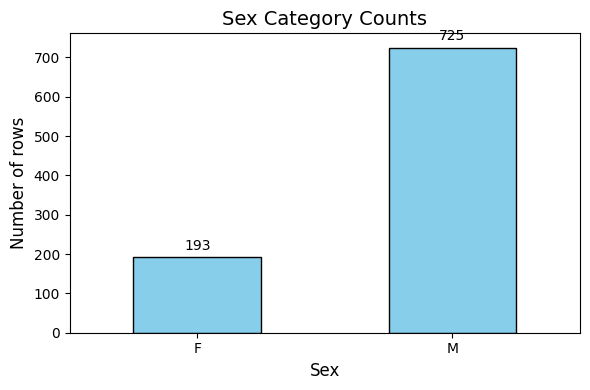

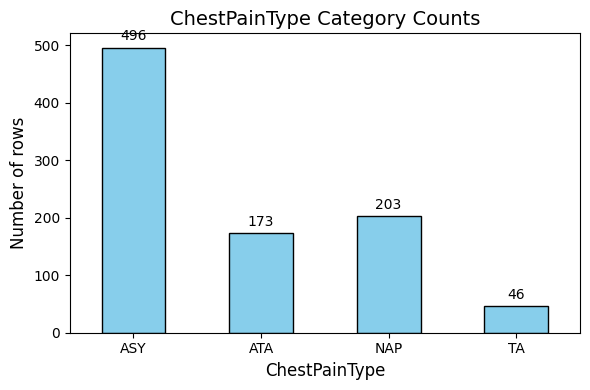

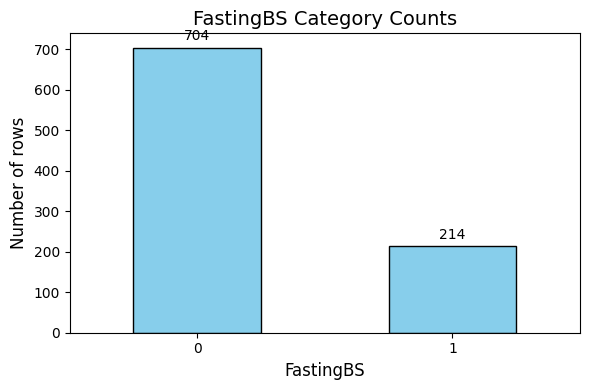

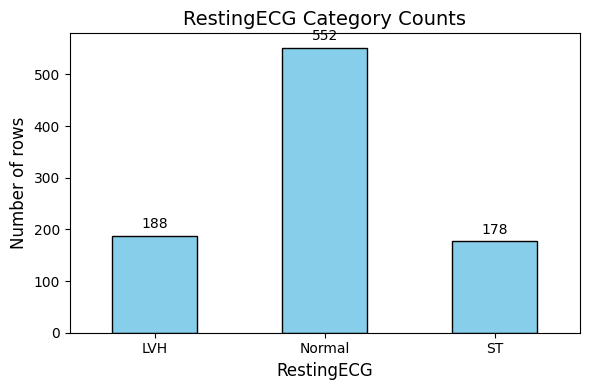

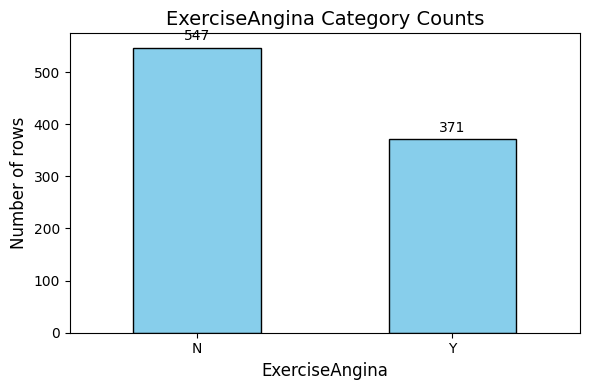

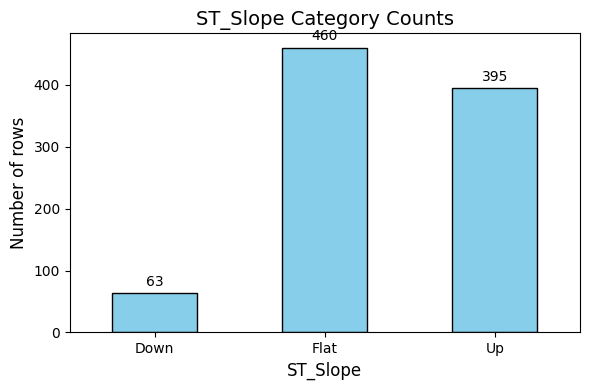

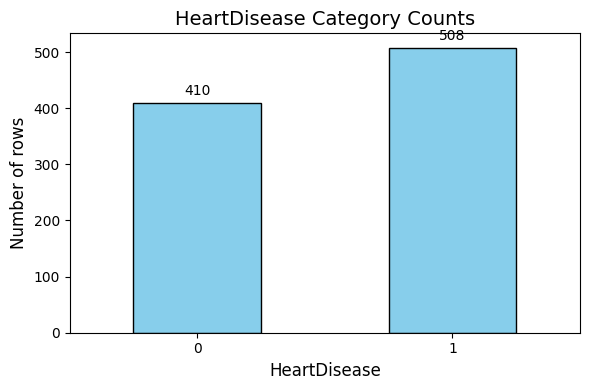

In [71]:
import matplotlib.pyplot as plt

categorical_cols = [
    'Sex',
    'ChestPainType',
    'FastingBS',
    'RestingECG',
    'ExerciseAngina',
    'ST_Slope',
    'HeartDisease'
]


for col in categorical_cols:
    counts = df[col].value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(6, 4))
    counts.plot(kind='bar', color='skyblue', edgecolor='black', ax=ax)
    ax.set_title(f'{col} Category Counts', fontsize=14)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Number of rows', fontsize=12)
    ax.bar_label(ax.containers[0], labels=[str(v) for v in counts.values], padding=3)
    ax.set_xticklabels([str(x) for x in counts.index], rotation=0)
    plt.tight_layout()
    plt.show()

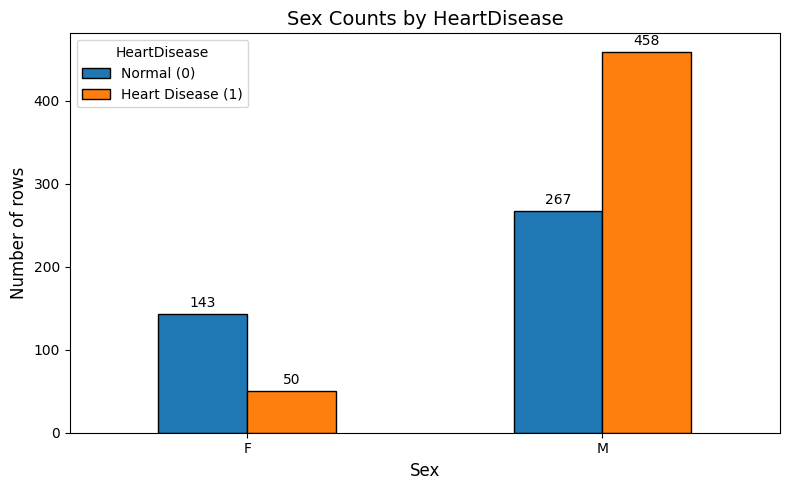

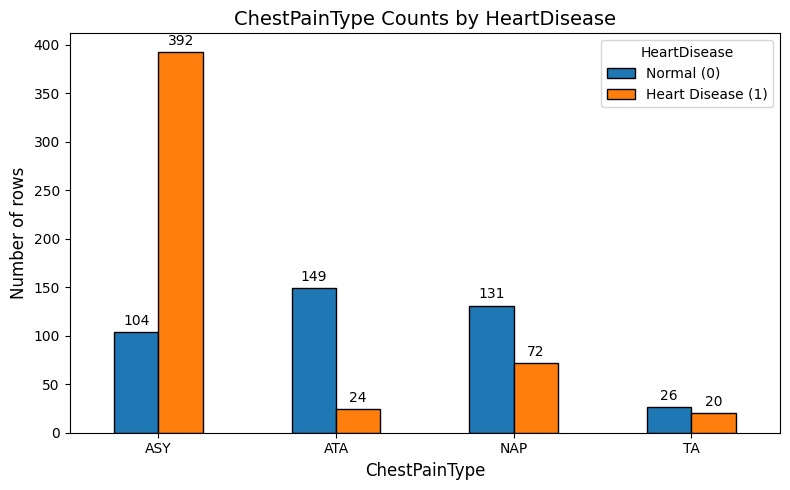

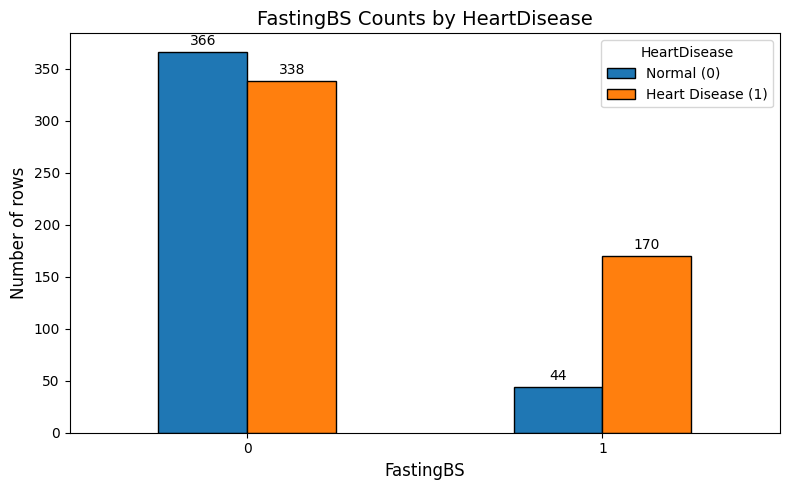

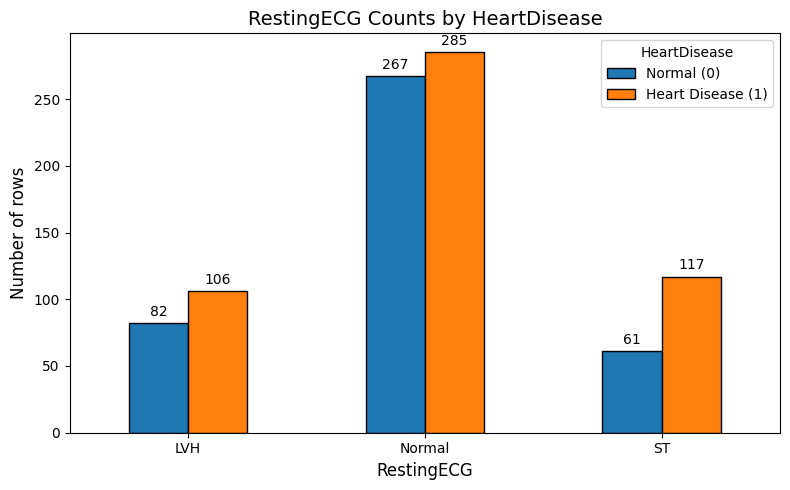

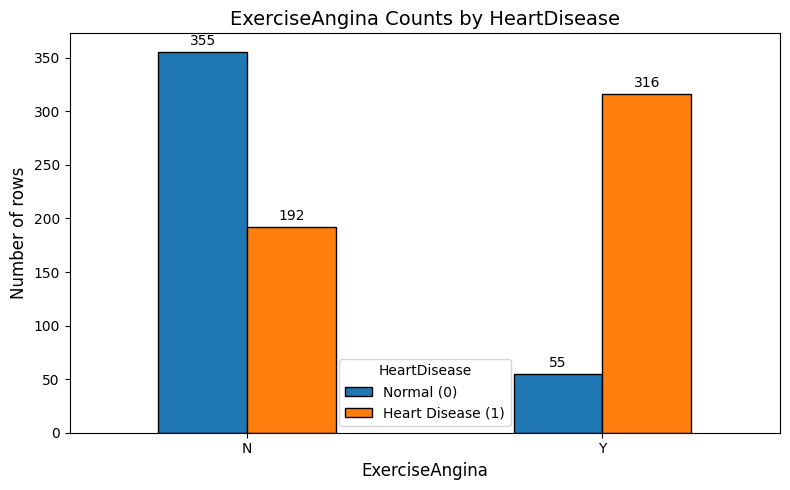

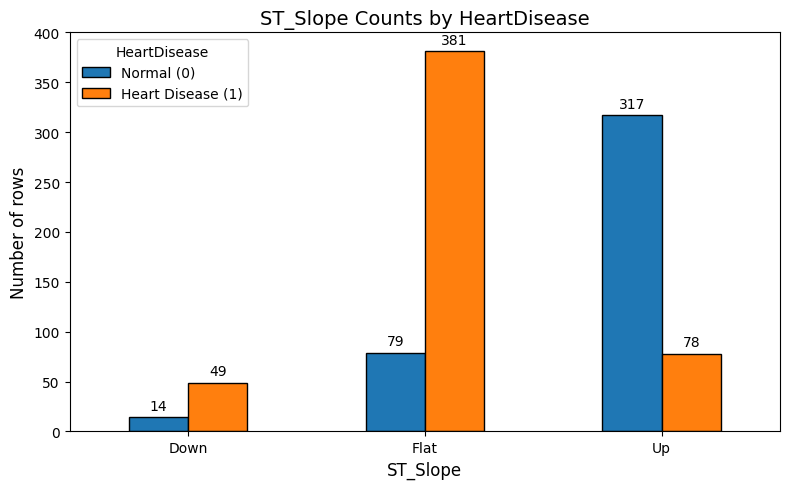

In [72]:
import matplotlib.pyplot as plt

categorical_cols = [
    'Sex',
    'ChestPainType',
    'FastingBS',
    'RestingECG',
    'ExerciseAngina',
    'ST_Slope'
]

for col in categorical_cols:
    grouped = df.groupby([col, 'HeartDisease']).size().unstack(fill_value=0)
    grouped = grouped.sort_index()

    fig, ax = plt.subplots(figsize=(8, 5))
    grouped.plot(kind='bar', ax=ax, edgecolor='black')

    ax.set_title(f'{col} Counts by HeartDisease', fontsize=14)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Number of rows', fontsize=12)
    ax.legend(title='HeartDisease', labels=['Normal (0)', 'Heart Disease (1)'])

    for container in ax.containers:
        ax.bar_label(container, padding=3)

    ax.set_xticklabels([str(x) for x in grouped.index], rotation=0)
    plt.tight_layout()
    plt.show()

- We can further notice how skewed the dataset is towards male patients. Only `50` female patients in the dataset have been diagnosed with heart disease.
- A significant number of patients, `392`, diagnosed with heart disease have asymptomatic (ASY) chest pain. While chest pain could be a relevant feature for our model, asymptomatic implies that those patients who had a heart disease did not have chest pain as a symptom. 
- A high number (`170`) of patients with blood sugar greater than 120 mg/dl were diagnosed with heart disease in relation to those who were not diagnosed as such.
- Out of all patients who had an exercise-induced angina, `316` were diagnosed with a heart disease.
- Out of all patients with a flat ST slope, `381` were diagnosed with a heart disease.

Looking at the data distribution from the above plots, we can start to identify some features that could be relevant to us. We will clean up the dataset a bit first before narrowing down on our features.

Patients diagnosed with heart disease: 508
Male patients over 50 with heart disease: 344 (67.7%)
Median age for patients with heart disease: 57.0


C:\Users\ademb\AppData\Local\Temp\ipykernel_14316\1739836609.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_grouped = df.groupby(['AgeGroup', 'HeartDisease']).size().unstack(fill_value=0)


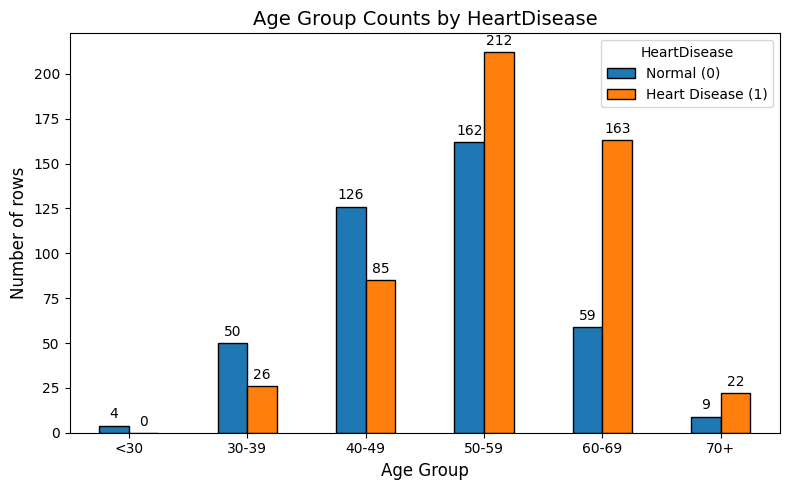

In [73]:
# Additional grouping and summary analysis for heart disease
heart_disease = df[df['HeartDisease'] == 1]
male_over_50 = heart_disease[(heart_disease['Sex'] == 'M') & (heart_disease['Age'] > 50)].shape[0]
total_hd = heart_disease.shape[0]
percent_male_over_50 = (male_over_50 / total_hd) * 100 if total_hd > 0 else 0
median_age_hd = heart_disease['Age'].median()

print(f"Patients diagnosed with heart disease: {total_hd}")
print(f"Male patients over 50 with heart disease: {male_over_50} ({percent_male_over_50:.1f}%)")
print(f"Median age for patients with heart disease: {median_age_hd}")

age_bins = [0, 30, 40, 50, 60, 70, 100]
age_labels = ['<30', '30-39', '40-49', '50-59', '60-69', '70+']

df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)
age_grouped = df.groupby(['AgeGroup', 'HeartDisease']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(8, 5))
age_grouped.plot(kind='bar', ax=ax, edgecolor='black')
ax.set_title('Age Group Counts by HeartDisease', fontsize=14)
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Number of rows', fontsize=12)
ax.legend(title='HeartDisease', labels=['Normal (0)', 'Heart Disease (1)'])
for container in ax.containers:
    ax.bar_label(container, padding=3)
ax.set_xticklabels(age_labels, rotation=0)
plt.tight_layout()
plt.show()

# Data Cleaning

In [74]:
df[df["RestingBP"] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,AgeGroup
449,55,M,NAP,0,0,0,Normal,155,N,1.5,Flat,1,50-59


In [75]:
df[df["Cholesterol"] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,AgeGroup
293,65,M,ASY,115,0,0,Normal,93,Y,0.0,Flat,1,60-69
294,32,M,TA,95,0,1,Normal,127,N,0.7,Up,1,30-39
295,61,M,ASY,105,0,1,Normal,110,Y,1.5,Up,1,60-69
296,50,M,ASY,145,0,1,Normal,139,Y,0.7,Flat,1,50-59
297,57,M,ASY,110,0,1,ST,131,Y,1.4,Up,1,50-59
...,...,...,...,...,...,...,...,...,...,...,...,...,...
514,43,M,ASY,122,0,0,Normal,120,N,0.5,Up,1,40-49
515,63,M,NAP,130,0,1,ST,160,N,3.0,Flat,0,60-69
518,48,M,NAP,102,0,1,ST,110,Y,1.0,Down,1,40-49
535,56,M,ASY,130,0,0,LVH,122,Y,1.0,Flat,1,50-59


In [78]:
df_clean = df.copy()

# Remove invalid RestingBP values
df_clean = df_clean[df_clean["RestingBP"] != 0]

# Replace Cholesterol=0 with group median (grouped by HeartDisease)
df_clean["Cholesterol"] = df_clean.groupby("HeartDisease")["Cholesterol"].transform(
    lambda x: x.replace(0, x.median())
)


In [79]:
df_clean[["Cholesterol", "RestingBP"]].describe()

,Cholesterol,RestingBP
count,917.000000,917.000000
mean,239.700109,132.540894
std,54.352727,17.999749
min,85.000000,80.000000
25%,214.000000,120.000000
50%,225.000000,130.000000
75%,267.000000,140.000000
max,603.000000,200.000000


The minimum values for both have changed! There are no more zero values in either of those.

# Feature Selection

In [82]:
df_clean = pd.get_dummies(df_clean, drop_first=True)
df_clean.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,...,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up,AgeGroup_30-39,AgeGroup_40-49,AgeGroup_50-59,AgeGroup_60-69,AgeGroup_70+
0,40,140,289,0,172,0.0,0,True,True,False,...,True,False,False,False,True,False,True,False,False,False
1,49,160,180,0,156,1.0,1,False,False,True,...,True,False,False,True,False,False,True,False,False,False
2,37,130,283,0,98,0.0,0,True,True,False,...,False,True,False,False,True,True,False,False,False,False
3,48,138,214,0,108,1.5,1,False,False,False,...,True,False,True,True,False,False,True,False,False,False
4,54,150,195,0,122,0.0,0,True,False,True,...,True,False,False,False,True,False,False,True,False,False


<Axes: >

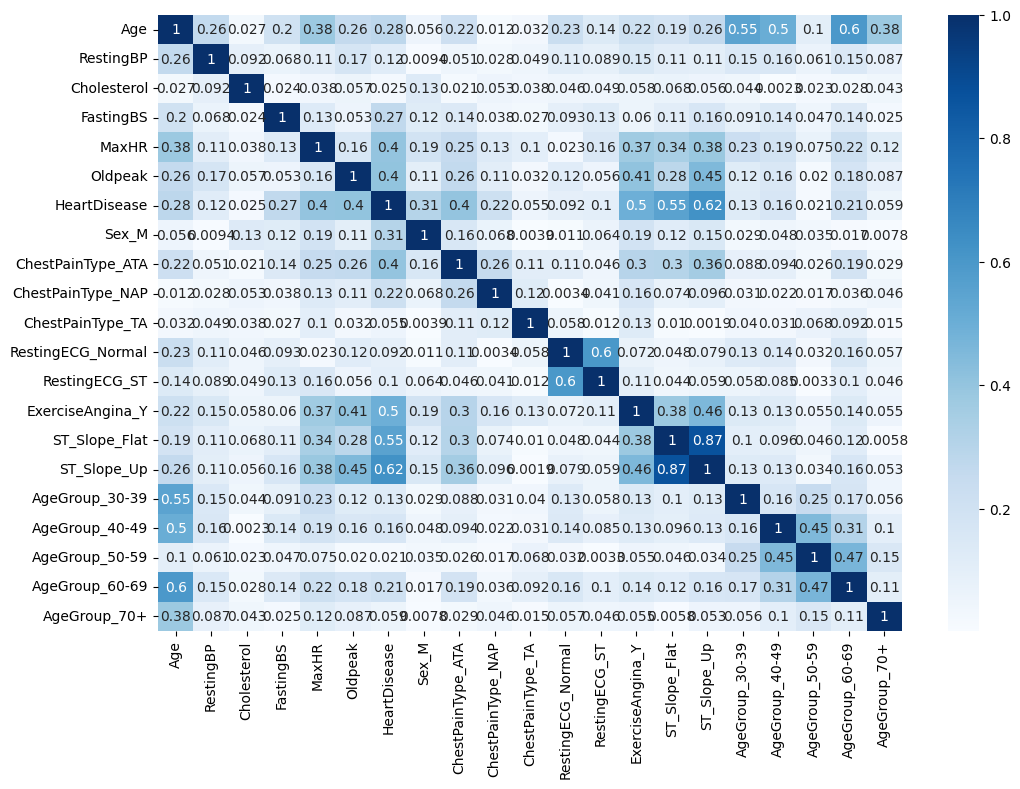

In [87]:
correlations = abs(df_clean.corr())
plt.figure(figsize=(12,8))
sns.heatmap(correlations, annot=True, cmap="Blues")

<Axes: >

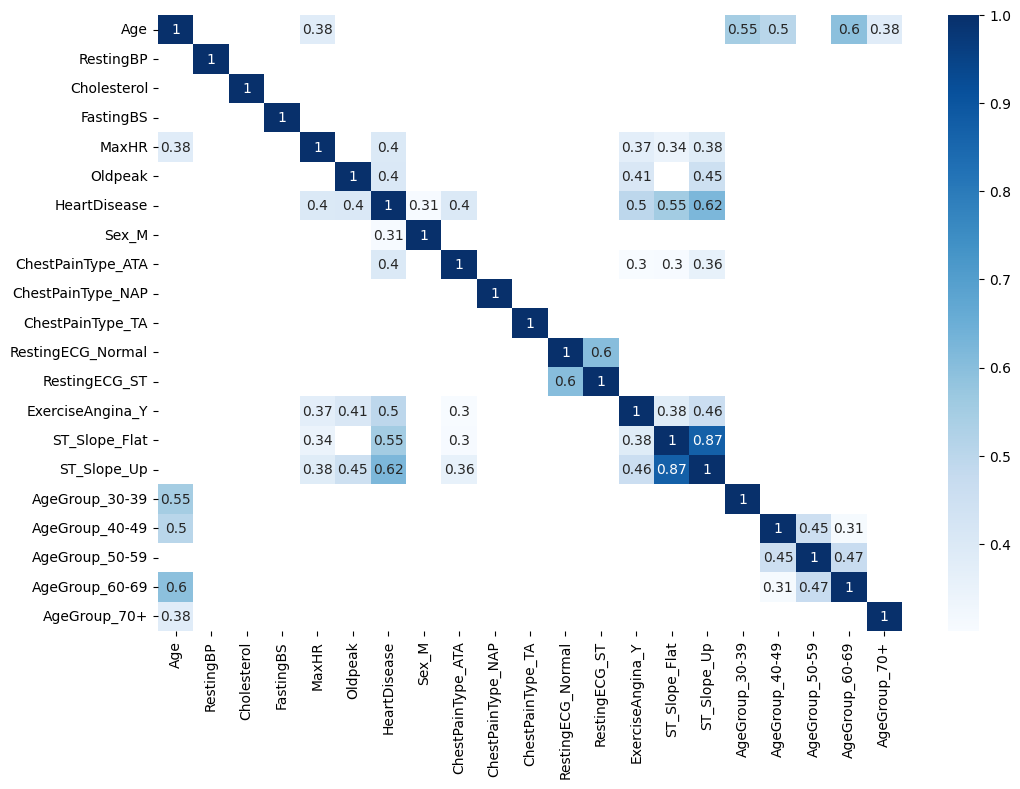

In [88]:
plt.figure(figsize=(12,8))
sns.heatmap(correlations[correlations > 0.3], annot=True, cmap="Blues")

From our correlation heatmap, we can identify the following features to be positively correlated (correlation coefficient greater than 0.3) to `HeartDisease`:

- `Oldpeak`
- `MaxHR`
- `ChestPainType_ATA` 
- `ExerciseAngina_Y`
- `ST_Slope_Flat`
- `ST_Slope_Up`

The correlation coefficient threshold was chosen arbitrarily. Surprisingly, `Cholesterol` is not strongly correlated to `HeartDisease`. We can consider ignoring the feature for now.

Given everything we have attempted so far, we can narrow down our features to the following:

- `Oldpeak`
- `Sex_M`
    - It has a relatively low value for the coefficient, but given what we observed in our EDA, let's also take it into account.
- `ExerciseAngina_Y`
- `ST_Slope_Flat`
- `ST_Slope_Up`

Time to create our model using these features!